# TabICL final held-out test evaluation

This notebook analyses the final fixed-context TabICL experiment.

Protocol:

- Training context size: \(N_c = 128\)
- Target size: \(N_t = 128\)
- Training budget: 500 epochs / 500,000 optimiser updates
- Evaluation tasks: 4,096 held-out, distinct tasks
- Evaluation samples: \(M_{\mathrm{eval}} = 64\)
- Evaluation score: fair CRPS, \(\alpha = 1\)

The three learned models are:

1. Gaussian likelihood TNP
2. MC Dropout CRPS-TNP
3. Stochastic LayerNorm CRPS-TNP

The models are compared with three context-only trivial baselines.

Bootstrap intervals in this notebook resample held-out tasks. They quantify
test-task variation, not variation across independently trained model seeds.

## Imports, repository root and paths

In [13]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_repository_root(start: Path | None = None) -> Path:
    """Find the repository root from either the repo or notebooks folder."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "experiments").is_dir()
            and (candidate / "tnp_crps").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the tnp-crps repository root from "
        f"{start}."
    )


ROOT = find_repository_root()

RESULT_DIR = (
    ROOT
    / "results"
    / "tabular"
    / "tabicl_nc128_500_test_v1"
)

METRICS_PATH = RESULT_DIR / "metrics.csv"
PER_TASK_PATH = RESULT_DIR / "per_task_metrics.csv"
CONFIG_PATH = RESULT_DIR / "eval_config_resolved.json"

OUTPUT_DIR = RESULT_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in (
    METRICS_PATH,
    PER_TASK_PATH,
    CONFIG_PATH,
):
    if not path.is_file():
        raise FileNotFoundError(path)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("Repository root:", ROOT)
print("Result directory:", RESULT_DIR)
print("Notebook outputs:", OUTPUT_DIR)

Repository root: /scratch2/ij292/tnp-crps
Result directory: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1
Notebook outputs: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs


## Load the result files

In [15]:
metrics = pd.read_csv(METRICS_PATH)
per_task = pd.read_csv(PER_TASK_PATH)

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    resolved_config = json.load(file)

print("Aggregate metric rows:", len(metrics))
print("Per-task metric rows:", len(per_task))
print("Evaluation output:", resolved_config["output_dir"])
print("Evaluation samples:", resolved_config["num_eval_samples"])
print("Tasks requested:", resolved_config["samples_per_eval_set"])

Aggregate metric rows: 12
Per-task metric rows: 24576
Evaluation output: results/tabular/tabicl_nc128_500_test_v1
Evaluation samples: 64
Tasks requested: 4096


## Model labels and integrity checks

In [16]:
MODEL_ORDER = [
    "dropout",
    "stochln",
    "gaussian",
    "context_resample",
    "context_gaussian",
    "context_mean",
]

MODEL_LABELS = {
    "dropout": "Dropout CRPS-TNP",
    "stochln": "StochLN CRPS-TNP",
    "gaussian": "Gaussian TNP",
    "context_resample": "Context resample",
    "context_gaussian": "Context Gaussian",
    "context_mean": "Context mean",
}

EXPECTED_MODELS = set(MODEL_ORDER)
EXPECTED_NUM_TASKS = 4096
EXPECTED_NUM_SAMPLES = 64


# Select one aggregate row per model.
headline = metrics[
    (metrics["region"] == "all")
    & (metrics["context_bucket"] == "all")
].copy()

if set(headline["model_name"]) != EXPECTED_MODELS:
    raise RuntimeError(
        "Unexpected aggregate model set. "
        f"Found: {sorted(headline['model_name'].unique())}"
    )

if len(headline) != len(EXPECTED_MODELS):
    raise RuntimeError(
        f"Expected {len(EXPECTED_MODELS)} aggregate rows, "
        f"found {len(headline)}."
    )


# Check that there is exactly one task row per model/task pair.
duplicates = per_task.duplicated(
    subset=["model_name", "task_index"],
    keep=False,
)

if duplicates.any():
    display(
        per_task.loc[
            duplicates,
            ["model_name", "task_index"],
        ].head()
    )
    raise RuntimeError(
        "Duplicate model/task rows found in per_task_metrics.csv."
    )


task_counts = (
    per_task.groupby("model_name")["task_index"]
    .agg(["count", "nunique", "min", "max"])
    .reindex(MODEL_ORDER)
)

display(task_counts)

assert set(per_task["model_name"]) == EXPECTED_MODELS
assert (task_counts["count"] == EXPECTED_NUM_TASKS).all()
assert (task_counts["nunique"] == EXPECTED_NUM_TASKS).all()
assert (task_counts["min"] == 0).all()
assert (task_counts["max"] == EXPECTED_NUM_TASKS - 1).all()


expected_task_indices = np.arange(EXPECTED_NUM_TASKS)

for model_name, model_rows in per_task.groupby("model_name"):
    actual_indices = np.sort(
        model_rows["task_index"].to_numpy()
    )

    if not np.array_equal(
        actual_indices,
        expected_task_indices,
    ):
        raise RuntimeError(
            f"Task indices are not complete for {model_name}."
        )


assert set(per_task["num_eval_samples"].unique()) == {
    EXPECTED_NUM_SAMPLES
}

assert np.allclose(
    per_task["metric_alpha"].to_numpy(),
    1.0,
)

assert int(resolved_config["num_eval_samples"]) == 64
assert int(resolved_config["samples_per_eval_set"]) == 4096

overrides = set(
    resolved_config["eval_sets"][0]["overrides"]
)

assert "generators.test.source.split=test" in overrides
assert "generators.test.source.cycle=false" in overrides
assert "generators.test.source.shuffle=false" in overrides

print("Final-test integrity checks passed.")

,count,nunique,min,max
model_name,,,,
dropout,4096,4096,0,4095
stochln,4096,4096,0,4095
gaussian,4096,4096,0,4095
context_resample,4096,4096,0,4095
context_gaussian,4096,4096,0,4095
context_mean,4096,4096,0,4095


Final-test integrity checks passed.


## Aggregate headline table

In [17]:
aggregate_columns = [
    "model_name",
    "rmse_pooled",
    "crps",
    "energy_score",
    "ensemble_spread",
    "spread_skill_ratio",
    "coverage_50",
    "coverage_80",
    "coverage_90",
    "coverage_95",
    "width_50",
    "width_80",
    "width_90",
    "width_95",
]

aggregate_table = headline[
    aggregate_columns
].copy()

aggregate_table["model"] = aggregate_table[
    "model_name"
].map(MODEL_LABELS)

aggregate_table["model_order"] = aggregate_table[
    "model_name"
].map(
    {
        model_name: index
        for index, model_name in enumerate(MODEL_ORDER)
    }
)

aggregate_table = (
    aggregate_table
    .sort_values("model_order")
    .drop(columns=["model_order", "model_name"])
)

aggregate_table = aggregate_table[
    ["model"] + [
        column
        for column in aggregate_table.columns
        if column != "model"
    ]
]

display(
    aggregate_table.style.format(
        {
            "rmse_pooled": "{:.6f}",
            "crps": "{:.6f}",
            "energy_score": "{:.6f}",
            "ensemble_spread": "{:.6f}",
            "spread_skill_ratio": "{:.6f}",
            "coverage_50": "{:.6f}",
            "coverage_80": "{:.6f}",
            "coverage_90": "{:.6f}",
            "coverage_95": "{:.6f}",
            "width_50": "{:.6f}",
            "width_80": "{:.6f}",
            "width_90": "{:.6f}",
            "width_95": "{:.6f}",
        }
    )
)

aggregate_table.to_csv(
    OUTPUT_DIR / "aggregate_test_metrics.csv",
    index=False,
)

print(
    "Wrote:",
    OUTPUT_DIR / "aggregate_test_metrics.csv",
)

,model,rmse_pooled,crps,energy_score,ensemble_spread,spread_skill_ratio,coverage_50,coverage_80,coverage_90,coverage_95,width_50,width_80,width_90,width_95
6,Dropout CRPS-TNP,0.899520,0.274667,5.611713,0.805946,0.902946,0.608599,0.841448,0.911507,0.947725,0.563267,1.133701,1.519635,1.903910
10,StochLN CRPS-TNP,0.924787,0.291489,6.148188,0.967328,1.054142,0.579283,0.826757,0.902128,0.941433,0.596174,1.205690,1.626524,2.074953
8,Gaussian TNP,0.923991,0.320895,5.964822,0.880010,0.959813,0.630804,0.858994,0.917482,0.945175,0.863537,1.624909,2.056960,2.406897
4,Context resample,1.154469,0.476898,8.607611,0.999930,0.872879,0.539606,0.800646,0.885839,0.931110,0.985487,1.940641,2.560683,3.164192
0,Context Gaussian,1.154284,0.532379,8.653961,0.999887,0.872981,0.583582,0.839552,0.905497,0.937153,1.319503,2.482171,3.141357,3.675884
2,Context mean,1.147626,0.714118,11.821590,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/aggregate_test_metrics.csv


## Task-level mean, median and quartile summaries

In [18]:
task_summary = (
    per_task.groupby("model_name", as_index=False)
    .agg(
        crps_mean=("crps", "mean"),
        crps_median=("crps", "median"),
        crps_q25=(
            "crps",
            lambda values: values.quantile(0.25),
        ),
        crps_q75=(
            "crps",
            lambda values: values.quantile(0.75),
        ),
        rmse_mean=("rmse", "mean"),
        rmse_median=("rmse", "median"),
        energy_score_mean=(
            "energy_score",
            "mean",
        ),
        energy_score_median=(
            "energy_score",
            "median",
        ),
        spread_mean=(
            "ensemble_spread",
            "mean",
        ),
        spread_skill_mean=(
            "spread_skill_ratio",
            "mean",
        ),
        coverage_90_mean=(
            "coverage_90",
            "mean",
        ),
        width_90_mean=(
            "width_90",
            "mean",
        ),
    )
)

task_summary["model"] = task_summary[
    "model_name"
].map(MODEL_LABELS)

task_summary["model_order"] = task_summary[
    "model_name"
].map(
    {
        model_name: index
        for index, model_name in enumerate(MODEL_ORDER)
    }
)

task_summary = (
    task_summary
    .sort_values("model_order")
    .drop(columns=["model_order", "model_name"])
)

task_summary = task_summary[
    ["model"] + [
        column
        for column in task_summary.columns
        if column != "model"
    ]
]

display(
    task_summary.style.format(
        {
            column: "{:.6f}"
            for column in task_summary.columns
            if column != "model"
        }
    )
)

task_summary.to_csv(
    OUTPUT_DIR / "task_level_summary.csv",
    index=False,
)

print(
    "Wrote:",
    OUTPUT_DIR / "task_level_summary.csv",
)

,model,crps_mean,crps_median,crps_q25,crps_q75,rmse_mean,rmse_median,energy_score_mean,energy_score_median,spread_mean,spread_skill_mean,coverage_90_mean,width_90_mean
3,Dropout CRPS-TNP,0.274667,0.242517,0.059503,0.473880,0.683306,0.657399,5.611713,5.272142,0.698064,1.621960,0.911507,1.519635
5,StochLN CRPS-TNP,0.291489,0.277138,0.078308,0.488549,0.718552,0.719275,6.148188,5.841859,0.796652,1.616104,0.902128,1.626524
4,Gaussian TNP,0.320895,0.329932,0.102109,0.519110,0.717966,0.713148,5.964822,5.875928,0.776253,1.506494,0.917482,2.056960
2,Context resample,0.476898,0.515942,0.415120,0.574710,1.054271,1.010708,8.607611,8.018584,0.999677,1.177634,0.885839,2.560683
0,Context Gaussian,0.532379,0.550121,0.478322,0.600637,1.054195,1.009238,8.653961,8.005418,0.999857,1.176718,0.905497,3.141357
1,Context mean,0.714118,0.763007,0.618919,0.860077,1.044891,1.000928,11.821590,11.324208,0.000000,0.000000,0.000000,0.000000


Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/task_level_summary.csv


In [3]:
aggregate_by_name = aggregate.set_index(
    "model_name"
)

trivial_names = [
    "context_mean",
    "context_gaussian",
    "context_resample",
]

best_trivial_name = (
    aggregate_by_name.loc[
        trivial_names,
        "crps",
    ]
    .idxmin()
)

best_trivial_crps = float(
    aggregate_by_name.loc[
        best_trivial_name,
        "crps",
    ]
)

print(
    "Best trivial baseline:",
    MODEL_LABELS[best_trivial_name],
    f"(CRPS={best_trivial_crps:.6f})",
)
print()

for model_name in (
    "dropout",
    "stochln",
    "gaussian",
):
    model_crps = float(
        aggregate_by_name.loc[
            model_name,
            "crps",
        ]
    )

    reduction = (
        100.0
        * (best_trivial_crps - model_crps)
        / best_trivial_crps
    )

    print(
        f"{MODEL_LABELS[model_name]}: "
        f"CRPS={model_crps:.6f}; "
        f"{reduction:.2f}% lower than "
        f"{MODEL_LABELS[best_trivial_name]}."
    )

dropout_vs_gaussian = (
    100.0
    * (
        float(
            aggregate_by_name.loc[
                "gaussian",
                "crps",
            ]
        )
        - float(
            aggregate_by_name.loc[
                "dropout",
                "crps",
            ]
        )
    )
    / float(
        aggregate_by_name.loc[
            "gaussian",
            "crps",
        ]
    )
)

print()
print(
    "Dropout CRPS reduction relative to "
    f"Gaussian TNP: {dropout_vs_gaussian:.2f}%."
)

Best trivial baseline: Context resample (CRPS=0.476898)

Dropout CRPS-TNP: CRPS=0.274667; 42.41% lower than Context resample.
StochLN CRPS-TNP: CRPS=0.291489; 38.88% lower than Context resample.
Gaussian TNP: CRPS=0.320895; 32.71% lower than Context resample.

Dropout CRPS reduction relative to Gaussian TNP: 14.41%.


## Check task means against aggregate metrics

In [19]:
aggregate_index = headline.set_index("model_name")

task_means = (
    per_task.groupby("model_name")[
        ["crps", "energy_score"]
    ]
    .mean()
    .rename(
        columns={
            "crps": "task_mean_crps",
            "energy_score": "task_mean_energy",
        }
    )
)

consistency = task_means.join(
    aggregate_index[
        ["crps", "energy_score"]
    ].rename(
        columns={
            "crps": "aggregate_crps",
            "energy_score": "aggregate_energy",
        }
    )
)

consistency["crps_abs_difference"] = (
    consistency["task_mean_crps"]
    - consistency["aggregate_crps"]
).abs()

consistency["energy_abs_difference"] = (
    consistency["task_mean_energy"]
    - consistency["aggregate_energy"]
).abs()

display(consistency)

assert consistency["crps_abs_difference"].max() < 1.0e-5
assert consistency["energy_abs_difference"].max() < 1.0e-4

print("Aggregate/per-task consistency checks passed.")

,task_mean_crps,task_mean_energy,aggregate_crps,aggregate_energy,crps_abs_difference,energy_abs_difference
model_name,,,,,,
context_gaussian,0.532379,8.653961,0.532379,8.653961,8.840289e-10,5.937181e-09
context_mean,0.714118,11.821590,0.714118,11.821590,1.808985e-09,4.497997e-08
context_resample,0.476898,8.607611,0.476898,8.607611,8.309372e-10,1.909211e-08
dropout,0.274667,5.611713,0.274667,5.611713,2.702193e-10,2.270826e-08
gaussian,0.320895,5.964822,0.320895,5.964822,7.939036e-10,1.123590e-08
stochln,0.291489,6.148188,0.291489,6.148188,7.399876e-10,6.467417e-09


Aggregate/per-task consistency checks passed.


## Relative improvements over the best trivial baseline

In [20]:
aggregate_lookup = headline.set_index("model_name")

reference_model = "context_resample"

reference_crps = float(
    aggregate_lookup.loc[
        reference_model,
        "crps",
    ]
)

reference_rmse = float(
    aggregate_lookup.loc[
        reference_model,
        "rmse_pooled",
    ]
)

reference_energy = float(
    aggregate_lookup.loc[
        reference_model,
        "energy_score",
    ]
)

gaussian_crps = float(
    aggregate_lookup.loc[
        "gaussian",
        "crps",
    ]
)

relative_rows = []

for model_name in (
    "dropout",
    "stochln",
    "gaussian",
):
    model_crps = float(
        aggregate_lookup.loc[
            model_name,
            "crps",
        ]
    )

    model_rmse = float(
        aggregate_lookup.loc[
            model_name,
            "rmse_pooled",
        ]
    )

    model_energy = float(
        aggregate_lookup.loc[
            model_name,
            "energy_score",
        ]
    )

    relative_rows.append(
        {
            "model_name": model_name,
            "model": MODEL_LABELS[model_name],
            "crps_reduction_vs_context_resample_pct": (
                100.0
                * (
                    reference_crps
                    - model_crps
                )
                / reference_crps
            ),
            "rmse_reduction_vs_context_resample_pct": (
                100.0
                * (
                    reference_rmse
                    - model_rmse
                )
                / reference_rmse
            ),
            "energy_reduction_vs_context_resample_pct": (
                100.0
                * (
                    reference_energy
                    - model_energy
                )
                / reference_energy
            ),
            "crps_reduction_vs_gaussian_pct": (
                100.0
                * (
                    gaussian_crps
                    - model_crps
                )
                / gaussian_crps
            ),
        }
    )

relative_improvements = pd.DataFrame(
    relative_rows
)

display(
    relative_improvements[
        [
            "model",
            "crps_reduction_vs_context_resample_pct",
            "rmse_reduction_vs_context_resample_pct",
            "energy_reduction_vs_context_resample_pct",
            "crps_reduction_vs_gaussian_pct",
        ]
    ].style.format(
        {
            "crps_reduction_vs_context_resample_pct": "{:.2f}%",
            "rmse_reduction_vs_context_resample_pct": "{:.2f}%",
            "energy_reduction_vs_context_resample_pct": "{:.2f}%",
            "crps_reduction_vs_gaussian_pct": "{:.2f}%",
        }
    )
)

relative_improvements.to_csv(
    OUTPUT_DIR / "relative_improvements.csv",
    index=False,
)

,model,crps_reduction_vs_context_resample_pct,rmse_reduction_vs_context_resample_pct,energy_reduction_vs_context_resample_pct,crps_reduction_vs_gaussian_pct
0,Dropout CRPS-TNP,42.41%,22.08%,34.81%,14.41%
1,StochLN CRPS-TNP,38.88%,19.90%,28.57%,9.16%
2,Gaussian TNP,32.71%,19.96%,30.70%,0.00%


## Paired task bootstrap

The following comparisons use paired resampling because all models were
evaluated on the same held-out tasks.

For each bootstrap replicate, the same task indices are sampled for both
models. A negative value of

\[
\mathrm{CRPS}_A - \mathrm{CRPS}_B
\]

indicates that model \(A\) has lower CRPS.

The intervals are unadjusted 95% percentile bootstrap intervals. They
represent variation over held-out tasks only and do not account for
training-seed uncertainty.

In [21]:
N_BOOTSTRAP = 10_000
BOOTSTRAP_SEED = 20260731
BOOTSTRAP_BATCH_SIZE = 250


def bootstrap_mean_interval(
    values: np.ndarray,
    *,
    n_bootstrap: int = N_BOOTSTRAP,
    seed: int = BOOTSTRAP_SEED,
    bootstrap_batch_size: int = BOOTSTRAP_BATCH_SIZE,
) -> dict[str, float]:
    """Bootstrap interval for the mean of one paired-task metric."""
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    if values.ndim != 1:
        raise ValueError(
            f"Expected one-dimensional values, got {values.shape}."
        )

    if not np.isfinite(values).all():
        raise ValueError(
            "Bootstrap values contain NaN or Inf."
        )

    rng = np.random.default_rng(seed)
    num_tasks = len(values)

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=np.float64,
    )

    for start in range(
        0,
        n_bootstrap,
        bootstrap_batch_size,
    ):
        stop = min(
            start + bootstrap_batch_size,
            n_bootstrap,
        )
        current_size = stop - start

        indices = rng.integers(
            low=0,
            high=num_tasks,
            size=(current_size, num_tasks),
        )

        bootstrap_means[start:stop] = (
            values[indices].mean(axis=1)
        )

    lower, upper = np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )

    return {
        "mean": float(values.mean()),
        "ci95_low": float(lower),
        "ci95_high": float(upper),
    }


def paired_bootstrap_crps(
    values_a: np.ndarray,
    values_b: np.ndarray,
    *,
    n_bootstrap: int = N_BOOTSTRAP,
    seed: int = BOOTSTRAP_SEED,
    bootstrap_batch_size: int = BOOTSTRAP_BATCH_SIZE,
) -> dict[str, float]:
    """Paired bootstrap comparison of mean task CRPS."""
    values_a = np.asarray(
        values_a,
        dtype=np.float64,
    )
    values_b = np.asarray(
        values_b,
        dtype=np.float64,
    )

    if values_a.shape != values_b.shape:
        raise ValueError(
            "Paired values must have identical shapes. "
            f"Got {values_a.shape} and {values_b.shape}."
        )

    if values_a.ndim != 1:
        raise ValueError(
            f"Expected one-dimensional values, got {values_a.shape}."
        )

    if (
        not np.isfinite(values_a).all()
        or not np.isfinite(values_b).all()
    ):
        raise ValueError(
            "Paired bootstrap values contain NaN or Inf."
        )

    num_tasks = len(values_a)
    rng = np.random.default_rng(seed)

    bootstrap_differences = np.empty(
        n_bootstrap,
        dtype=np.float64,
    )

    bootstrap_relative_reductions = np.empty(
        n_bootstrap,
        dtype=np.float64,
    )

    for start in range(
        0,
        n_bootstrap,
        bootstrap_batch_size,
    ):
        stop = min(
            start + bootstrap_batch_size,
            n_bootstrap,
        )
        current_size = stop - start

        indices = rng.integers(
            low=0,
            high=num_tasks,
            size=(current_size, num_tasks),
        )

        means_a = values_a[indices].mean(
            axis=1
        )
        means_b = values_b[indices].mean(
            axis=1
        )

        bootstrap_differences[start:stop] = (
            means_a - means_b
        )

        bootstrap_relative_reductions[
            start:stop
        ] = (
            100.0
            * (means_b - means_a)
            / means_b
        )

    difference_lower, difference_upper = np.quantile(
        bootstrap_differences,
        [0.025, 0.975],
    )

    relative_lower, relative_upper = np.quantile(
        bootstrap_relative_reductions,
        [0.025, 0.975],
    )

    observed_difference = float(
        values_a.mean()
        - values_b.mean()
    )

    observed_relative_reduction = float(
        100.0
        * (
            values_b.mean()
            - values_a.mean()
        )
        / values_b.mean()
    )

    return {
        "num_tasks": num_tasks,
        "num_bootstrap": n_bootstrap,
        "mean_crps_a": float(
            values_a.mean()
        ),
        "mean_crps_b": float(
            values_b.mean()
        ),
        "mean_difference_a_minus_b": (
            observed_difference
        ),
        "difference_ci95_low": float(
            difference_lower
        ),
        "difference_ci95_high": float(
            difference_upper
        ),
        "relative_reduction_pct": (
            observed_relative_reduction
        ),
        "relative_reduction_ci95_low": float(
            relative_lower
        ),
        "relative_reduction_ci95_high": float(
            relative_upper
        ),
        "task_win_rate_pct": float(
            100.0
            * np.mean(values_a < values_b)
        ),
        "bootstrap_probability_a_better": float(
            np.mean(
                bootstrap_differences < 0.0
            )
        ),
    }

## Paired CRPS comparisons

In [22]:
crps_by_task = per_task.pivot(
    index="task_index",
    columns="model_name",
    values="crps",
).sort_index()

if crps_by_task.isna().any().any():
    raise RuntimeError(
        "Missing values found in paired CRPS matrix."
    )

if set(crps_by_task.columns) != EXPECTED_MODELS:
    raise RuntimeError(
        "Unexpected models in paired CRPS matrix."
    )

comparisons = [
    ("dropout", "gaussian"),
    ("stochln", "gaussian"),
    ("dropout", "stochln"),
    ("dropout", "context_resample"),
    ("stochln", "context_resample"),
    ("gaussian", "context_resample"),
]

comparison_rows = []

for comparison_index, (
    model_a,
    model_b,
) in enumerate(comparisons):
    result = paired_bootstrap_crps(
        crps_by_task[model_a].to_numpy(),
        crps_by_task[model_b].to_numpy(),
        seed=(
            BOOTSTRAP_SEED
            + comparison_index
        ),
    )

    result.update(
        {
            "model_a": model_a,
            "model_b": model_b,
            "model_a_label": (
                MODEL_LABELS[model_a]
            ),
            "model_b_label": (
                MODEL_LABELS[model_b]
            ),
        }
    )

    if result["difference_ci95_high"] < 0.0:
        result["interpretation"] = (
            "Model A has lower paired mean CRPS"
        )
    elif result["difference_ci95_low"] > 0.0:
        result["interpretation"] = (
            "Model A has higher paired mean CRPS"
        )
    else:
        result["interpretation"] = (
            "Paired interval crosses zero"
        )

    comparison_rows.append(result)

paired_comparisons = pd.DataFrame(
    comparison_rows
)

display_columns = [
    "model_a_label",
    "model_b_label",
    "mean_crps_a",
    "mean_crps_b",
    "mean_difference_a_minus_b",
    "difference_ci95_low",
    "difference_ci95_high",
    "relative_reduction_pct",
    "relative_reduction_ci95_low",
    "relative_reduction_ci95_high",
    "task_win_rate_pct",
    "bootstrap_probability_a_better",
    "interpretation",
]

display(
    paired_comparisons[
        display_columns
    ].style.format(
        {
            "mean_crps_a": "{:.6f}",
            "mean_crps_b": "{:.6f}",
            "mean_difference_a_minus_b": "{:.6f}",
            "difference_ci95_low": "{:.6f}",
            "difference_ci95_high": "{:.6f}",
            "relative_reduction_pct": "{:.2f}%",
            "relative_reduction_ci95_low": "{:.2f}%",
            "relative_reduction_ci95_high": "{:.2f}%",
            "task_win_rate_pct": "{:.2f}%",
            "bootstrap_probability_a_better": "{:.4f}",
        }
    )
)

paired_comparisons.to_csv(
    OUTPUT_DIR / "paired_crps_bootstrap.csv",
    index=False,
)

print(
    "Wrote:",
    OUTPUT_DIR / "paired_crps_bootstrap.csv",
)

,model_a_label,model_b_label,mean_crps_a,mean_crps_b,mean_difference_a_minus_b,difference_ci95_low,difference_ci95_high,relative_reduction_pct,relative_reduction_ci95_low,relative_reduction_ci95_high,task_win_rate_pct,bootstrap_probability_a_better,interpretation
0,Dropout CRPS-TNP,Gaussian TNP,0.274667,0.320895,-0.046228,-0.048007,-0.044490,14.41%,13.85%,14.98%,82.93%,1.0000,Model A has lower paired mean CRPS
1,StochLN CRPS-TNP,Gaussian TNP,0.291489,0.320895,-0.029406,-0.031120,-0.027781,9.16%,8.66%,9.68%,69.24%,1.0000,Model A has lower paired mean CRPS
2,Dropout CRPS-TNP,StochLN CRPS-TNP,0.274667,0.291489,-0.016822,-0.017778,-0.015867,5.77%,5.42%,6.12%,71.17%,1.0000,Model A has lower paired mean CRPS
3,Dropout CRPS-TNP,Context resample,0.274667,0.476898,-0.202230,-0.208354,-0.196221,42.41%,41.18%,43.62%,85.42%,1.0000,Model A has lower paired mean CRPS
4,StochLN CRPS-TNP,Context resample,0.291489,0.476898,-0.185408,-0.191374,-0.179571,38.88%,37.72%,40.07%,83.47%,1.0000,Model A has lower paired mean CRPS
5,Gaussian TNP,Context resample,0.320895,0.476898,-0.156002,-0.162621,-0.149252,32.71%,31.38%,34.01%,68.90%,1.0000,Model A has lower paired mean CRPS


Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/paired_crps_bootstrap.csv


## Final aggregate table with CRPS bootstrap intervals

In [23]:
crps_interval_rows = []

for model_index, model_name in enumerate(
    MODEL_ORDER
):
    model_values = (
        per_task.loc[
            per_task["model_name"]
            == model_name,
            "crps",
        ]
        .sort_index()
        .to_numpy()
    )

    interval = bootstrap_mean_interval(
        model_values,
        seed=(
            BOOTSTRAP_SEED
            + 100
            + model_index
        ),
    )

    crps_interval_rows.append(
        {
            "model_name": model_name,
            "crps_task_mean": interval["mean"],
            "crps_ci95_low": interval["ci95_low"],
            "crps_ci95_high": interval["ci95_high"],
        }
    )

crps_intervals = pd.DataFrame(
    crps_interval_rows
)

task_medians = (
    per_task.groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        crps_task_median=("crps", "median"),
        rmse_task_median=("rmse", "median"),
        energy_task_median=(
            "energy_score",
            "median",
        ),
    )
)

final_table = (
    headline[
        [
            "model_name",
            "rmse_pooled",
            "crps",
            "energy_score",
            "ensemble_spread",
            "spread_skill_ratio",
            "coverage_90",
            "width_90",
        ]
    ]
    .merge(
        crps_intervals,
        on="model_name",
        how="left",
    )
    .merge(
        task_medians,
        on="model_name",
        how="left",
    )
)

final_table["model"] = final_table[
    "model_name"
].map(MODEL_LABELS)

final_table = (
    final_table
    .sort_values("crps")
    [
        [
            "model",
            "rmse_pooled",
            "rmse_task_median",
            "crps",
            "crps_task_median",
            "crps_ci95_low",
            "crps_ci95_high",
            "energy_score",
            "energy_task_median",
            "ensemble_spread",
            "spread_skill_ratio",
            "coverage_90",
            "width_90",
        ]
    ]
    .reset_index(drop=True)
)

display(
    final_table.style.format(
        {
            column: "{:.6f}"
            for column in final_table.columns
            if column != "model"
        }
    )
)

final_table.to_csv(
    OUTPUT_DIR / "final_test_table_with_intervals.csv",
    index=False,
)

print(
    "Wrote:",
    OUTPUT_DIR
    / "final_test_table_with_intervals.csv",
)

,model,rmse_pooled,rmse_task_median,crps,crps_task_median,crps_ci95_low,crps_ci95_high,energy_score,energy_task_median,ensemble_spread,spread_skill_ratio,coverage_90,width_90
0,Dropout CRPS-TNP,0.899520,0.657399,0.274667,0.242517,0.267886,0.281282,5.611713,5.272142,0.805946,0.902946,0.911507,1.519635
1,StochLN CRPS-TNP,0.924787,0.719275,0.291489,0.277138,0.284740,0.298020,6.148188,5.841859,0.967328,1.054142,0.902128,1.626524
2,Gaussian TNP,0.923991,0.713148,0.320895,0.329932,0.313949,0.327711,5.964822,5.875928,0.880010,0.959813,0.917482,2.056960
3,Context resample,1.154469,1.010708,0.476898,0.515942,0.471919,0.481860,8.607611,8.018584,0.999930,0.872879,0.885839,2.560683
4,Context Gaussian,1.154284,1.009238,0.532379,0.550121,0.528759,0.535980,8.653961,8.005418,0.999887,0.872981,0.905497,3.141357
5,Context mean,1.147626,1.000928,0.714118,0.763007,0.707483,0.720841,11.821590,11.324208,0.000000,0.000000,0.000000,0.000000


Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/final_test_table_with_intervals.csv


## Aggregate CRPS plot

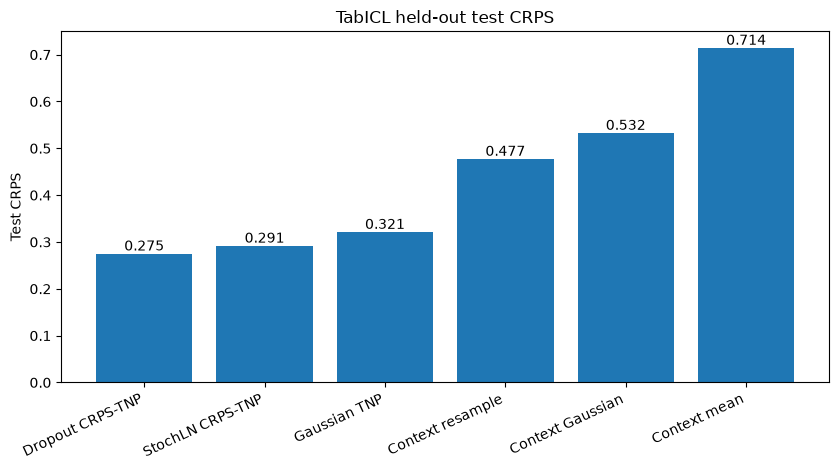

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/aggregate_test_crps.png


In [24]:
plot_data = (
    headline[
        ["model_name", "crps"]
    ]
    .sort_values("crps")
    .copy()
)

plot_data["label"] = plot_data[
    "model_name"
].map(MODEL_LABELS)

fig, ax = plt.subplots(
    figsize=(8.5, 4.8)
)

positions = np.arange(
    len(plot_data)
)

bars = ax.bar(
    positions,
    plot_data["crps"],
)

ax.set_xticks(
    positions,
    plot_data["label"],
    rotation=25,
    ha="right",
)

ax.set_ylabel("Test CRPS")
ax.set_title(
    "TabICL held-out test CRPS"
)

for bar, value in zip(
    bars,
    plot_data["crps"],
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2.0,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

figure_path = (
    OUTPUT_DIR / "aggregate_test_crps.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

## Per-task CRPS empirical CDF
This plot shows the central 99% of task-level CRPS values so a 
few extreme tasks do not compress the visible comparison.

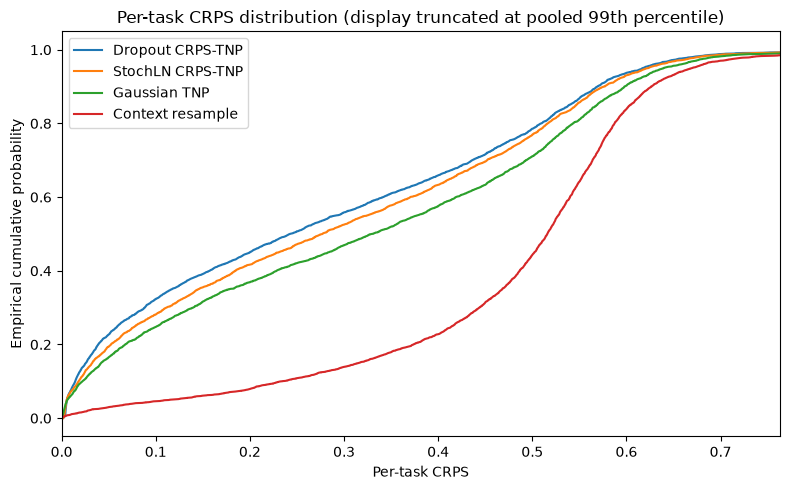

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/per_task_crps_ecdf.png


In [25]:
ecdf_models = [
    "dropout",
    "stochln",
    "gaussian",
    "context_resample",
]

ecdf_data = per_task[
    per_task["model_name"].isin(
        ecdf_models
    )
]

x_limit = float(
    ecdf_data["crps"].quantile(0.99)
)

fig, ax = plt.subplots(
    figsize=(8.0, 5.0)
)

for model_name in ecdf_models:
    values = np.sort(
        per_task.loc[
            per_task["model_name"]
            == model_name,
            "crps",
        ].to_numpy()
    )

    cumulative_probability = (
        np.arange(1, len(values) + 1)
        / len(values)
    )

    ax.plot(
        values,
        cumulative_probability,
        label=MODEL_LABELS[model_name],
    )

ax.set_xlim(
    left=0.0,
    right=x_limit,
)

ax.set_xlabel("Per-task CRPS")
ax.set_ylabel("Empirical cumulative probability")
ax.set_title(
    "Per-task CRPS distribution "
    "(display truncated at pooled 99th percentile)"
)
ax.legend()

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "per_task_crps_ecdf.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

## Marginal interval calibration plot

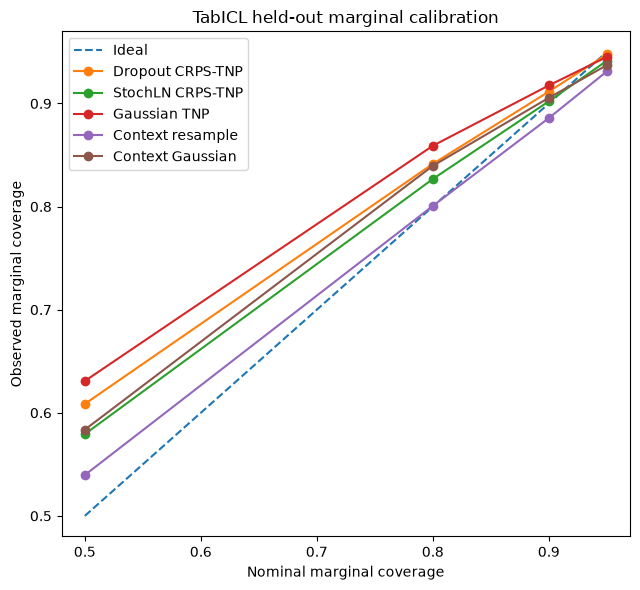

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/marginal_coverage_calibration.png


In [26]:
nominal_levels = np.array(
    [0.50, 0.80, 0.90, 0.95]
)

calibration_models = [
    "dropout",
    "stochln",
    "gaussian",
    "context_resample",
    "context_gaussian",
]

headline_lookup = headline.set_index(
    "model_name"
)

fig, ax = plt.subplots(
    figsize=(6.5, 6.0)
)

ax.plot(
    nominal_levels,
    nominal_levels,
    linestyle="--",
    label="Ideal",
)

for model_name in calibration_models:
    observed_coverage = np.array(
        [
            float(
                headline_lookup.loc[
                    model_name,
                    f"coverage_{int(level * 100):02d}",
                ]
            )
            for level in nominal_levels
        ]
    )

    ax.plot(
        nominal_levels,
        observed_coverage,
        marker="o",
        label=MODEL_LABELS[model_name],
    )

ax.set_xlabel("Nominal marginal coverage")
ax.set_ylabel("Observed marginal coverage")
ax.set_title(
    "TabICL held-out marginal calibration"
)
ax.set_xlim(0.48, 0.97)
ax.set_ylim(0.48, 0.97)
ax.legend()

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "marginal_coverage_calibration.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

## Spread–skill ratios

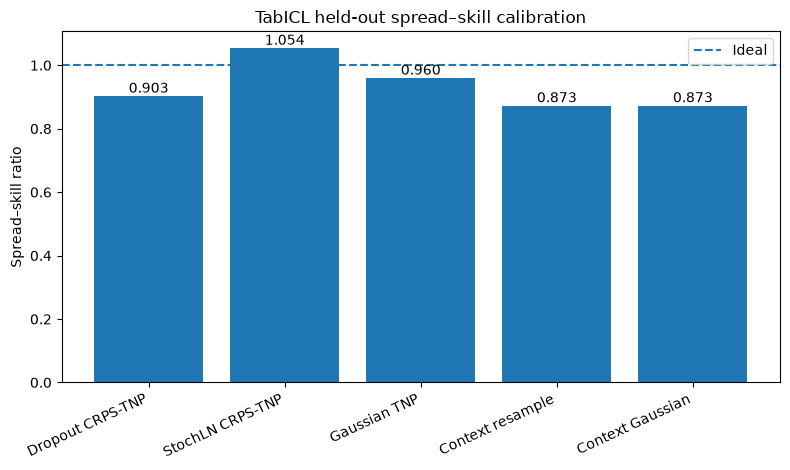

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/spread_skill_ratio.png


In [27]:
spread_models = [
    "dropout",
    "stochln",
    "gaussian",
    "context_resample",
    "context_gaussian",
]

spread_table = (
    headline_lookup.loc[
        spread_models,
        ["spread_skill_ratio"],
    ]
    .reset_index()
)

spread_table["label"] = spread_table[
    "model_name"
].map(MODEL_LABELS)

fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

positions = np.arange(
    len(spread_table)
)

bars = ax.bar(
    positions,
    spread_table["spread_skill_ratio"],
)

ax.axhline(
    1.0,
    linestyle="--",
    label="Ideal",
)

ax.set_xticks(
    positions,
    spread_table["label"],
    rotation=25,
    ha="right",
)

ax.set_ylabel("Spread–skill ratio")
ax.set_title(
    "TabICL held-out spread–skill calibration"
)
ax.legend()

for bar, value in zip(
    bars,
    spread_table["spread_skill_ratio"],
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2.0,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "spread_skill_ratio.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

## Task-wise paired CRPS differences

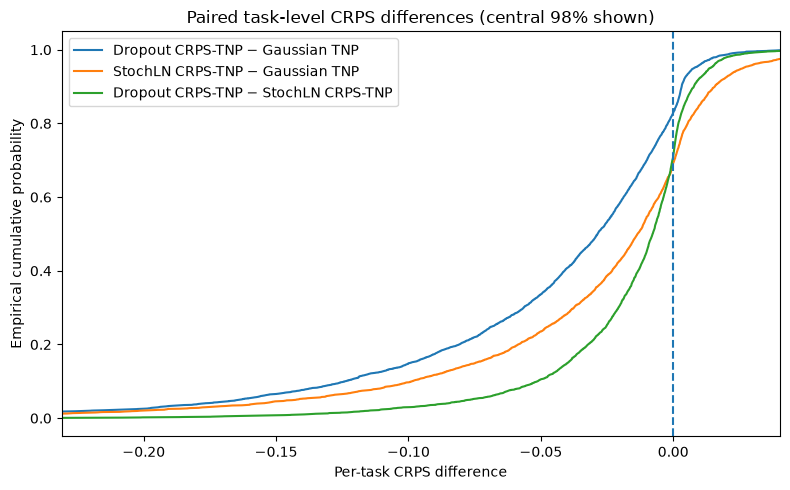

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/paired_task_crps_differences.png


In [28]:
difference_comparisons = [
    ("dropout", "gaussian"),
    ("stochln", "gaussian"),
    ("dropout", "stochln"),
]

all_differences = []

for model_a, model_b in difference_comparisons:
    differences = (
        crps_by_task[model_a]
        - crps_by_task[model_b]
    ).to_numpy()

    all_differences.append(differences)

combined_differences = np.concatenate(
    all_differences
)

lower_limit = float(
    np.quantile(
        combined_differences,
        0.01,
    )
)

upper_limit = float(
    np.quantile(
        combined_differences,
        0.99,
    )
)

fig, ax = plt.subplots(
    figsize=(8.0, 5.0)
)

for (
    model_a,
    model_b,
), differences in zip(
    difference_comparisons,
    all_differences,
):
    sorted_differences = np.sort(
        differences
    )

    cumulative_probability = (
        np.arange(
            1,
            len(sorted_differences) + 1,
        )
        / len(sorted_differences)
    )

    ax.plot(
        sorted_differences,
        cumulative_probability,
        label=(
            f"{MODEL_LABELS[model_a]} − "
            f"{MODEL_LABELS[model_b]}"
        ),
    )

ax.axvline(
    0.0,
    linestyle="--",
)

ax.set_xlim(
    lower_limit,
    upper_limit,
)

ax.set_xlabel("Per-task CRPS difference")
ax.set_ylabel("Empirical cumulative probability")
ax.set_title(
    "Paired task-level CRPS differences "
    "(central 98% shown)"
)
ax.legend()

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "paired_task_crps_differences.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", figure_path)

## Automatic result summary

In [29]:
best_crps_row = headline.sort_values(
    "crps"
).iloc[0]

best_rmse_row = headline.sort_values(
    "rmse_pooled"
).iloc[0]

best_energy_row = headline.sort_values(
    "energy_score"
).iloc[0]


paired_lookup = paired_comparisons.set_index(
    ["model_a", "model_b"]
)


def paired_result_sentence(
    model_a: str,
    model_b: str,
) -> str:
    row = paired_lookup.loc[
        (model_a, model_b)
    ]

    difference = float(
        row["mean_difference_a_minus_b"]
    )
    lower = float(
        row["difference_ci95_low"]
    )
    upper = float(
        row["difference_ci95_high"]
    )
    relative = float(
        row["relative_reduction_pct"]
    )

    if upper < 0.0:
        conclusion = (
            f"{MODEL_LABELS[model_a]} has lower "
            f"mean held-out task CRPS than "
            f"{MODEL_LABELS[model_b]}"
        )
    elif lower > 0.0:
        conclusion = (
            f"{MODEL_LABELS[model_a]} has higher "
            f"mean held-out task CRPS than "
            f"{MODEL_LABELS[model_b]}"
        )
    else:
        conclusion = (
            f"the paired mean-CRPS difference between "
            f"{MODEL_LABELS[model_a]} and "
            f"{MODEL_LABELS[model_b]} is not resolved "
            f"by this interval"
        )

    return (
        f"{conclusion}: mean difference "
        f"{difference:.6f}, unadjusted paired-bootstrap "
        f"95% interval [{lower:.6f}, {upper:.6f}], "
        f"relative CRPS reduction {relative:.2f}%."
    )


dropout_spread_skill = float(
    headline_lookup.loc[
        "dropout",
        "spread_skill_ratio",
    ]
)

stochln_spread_skill = float(
    headline_lookup.loc[
        "stochln",
        "spread_skill_ratio",
    ]
)

gaussian_spread_skill = float(
    headline_lookup.loc[
        "gaussian",
        "spread_skill_ratio",
    ]
)

summary_markdown = f"""
## Main test findings

- The lowest aggregate test CRPS is achieved by
  **{MODEL_LABELS[best_crps_row["model_name"]]}**
  with CRPS **{best_crps_row["crps"]:.6f}**.

- The lowest pooled RMSE is achieved by
  **{MODEL_LABELS[best_rmse_row["model_name"]]}**
  with RMSE **{best_rmse_row["rmse_pooled"]:.6f}**.

- The lowest function-level energy score is achieved by
  **{MODEL_LABELS[best_energy_row["model_name"]]}**
  with energy score **{best_energy_row["energy_score"]:.6f}**.

- {paired_result_sentence("dropout", "gaussian")}

- {paired_result_sentence("stochln", "gaussian")}

- {paired_result_sentence("dropout", "stochln")}

- Relative to the context-resampling baseline:
  - Dropout reduces aggregate CRPS by
    **{relative_improvements.set_index("model_name").loc["dropout", "crps_reduction_vs_context_resample_pct"]:.2f}%**.
  - StochLN reduces aggregate CRPS by
    **{relative_improvements.set_index("model_name").loc["stochln", "crps_reduction_vs_context_resample_pct"]:.2f}%**.
  - Gaussian TNP reduces aggregate CRPS by
    **{relative_improvements.set_index("model_name").loc["gaussian", "crps_reduction_vs_context_resample_pct"]:.2f}%**.

## Calibration

- Dropout spread–skill ratio:
  **{dropout_spread_skill:.3f}**.
- StochLN spread–skill ratio:
  **{stochln_spread_skill:.3f}**.
- Gaussian spread–skill ratio:
  **{gaussian_spread_skill:.3f}**.

A spread–skill ratio below one indicates average underdispersion,
whereas a value above one indicates average overdispersion.

## Interpretation boundary

The paired bootstrap intervals quantify variability across the 4,096
held-out tasks. Because only one trained seed is evaluated for each
model family, they do not establish robustness to training
initialisation.
"""

display(
    Markdown(summary_markdown)
)


## Main test findings

- The lowest aggregate test CRPS is achieved by
  **Dropout CRPS-TNP**
  with CRPS **0.274667**.

- The lowest pooled RMSE is achieved by
  **Dropout CRPS-TNP**
  with RMSE **0.899520**.

- The lowest function-level energy score is achieved by
  **Dropout CRPS-TNP**
  with energy score **5.611713**.

- Dropout CRPS-TNP has lower mean held-out task CRPS than Gaussian TNP: mean difference -0.046228, unadjusted paired-bootstrap 95% interval [-0.048007, -0.044490], relative CRPS reduction 14.41%.

- StochLN CRPS-TNP has lower mean held-out task CRPS than Gaussian TNP: mean difference -0.029406, unadjusted paired-bootstrap 95% interval [-0.031120, -0.027781], relative CRPS reduction 9.16%.

- Dropout CRPS-TNP has lower mean held-out task CRPS than StochLN CRPS-TNP: mean difference -0.016822, unadjusted paired-bootstrap 95% interval [-0.017778, -0.015867], relative CRPS reduction 5.77%.

- Relative to the context-resampling baseline:
  - Dropout reduces aggregate CRPS by
    **42.41%**.
  - StochLN reduces aggregate CRPS by
    **38.88%**.
  - Gaussian TNP reduces aggregate CRPS by
    **32.71%**.

## Calibration

- Dropout spread–skill ratio:
  **0.903**.
- StochLN spread–skill ratio:
  **1.054**.
- Gaussian spread–skill ratio:
  **0.960**.

A spread–skill ratio below one indicates average underdispersion,
whereas a value above one indicates average overdispersion.

## Interpretation boundary

The paired bootstrap intervals quantify variability across the 4,096
held-out tasks. Because only one trained seed is evaluated for each
model family, they do not establish robustness to training
initialisation.


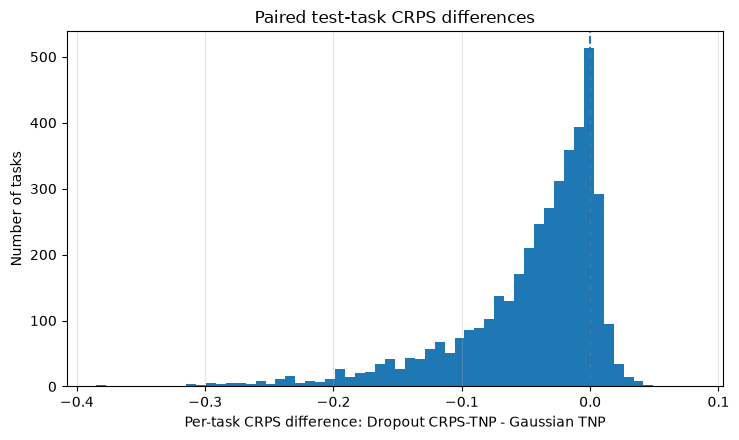

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/dropout_minus_gaussian_crps.png


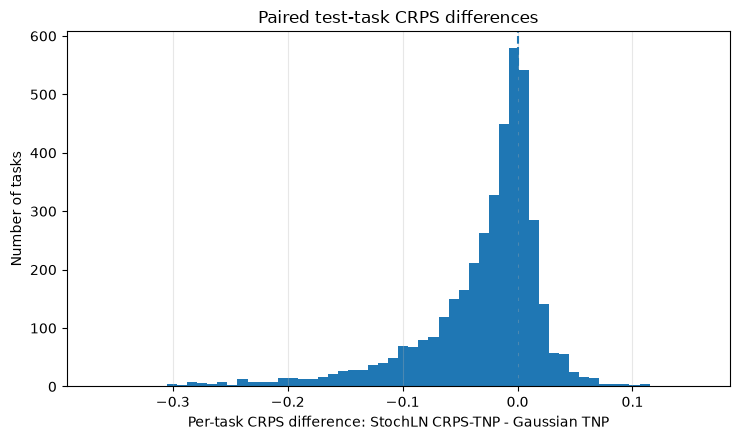

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/stochln_minus_gaussian_crps.png


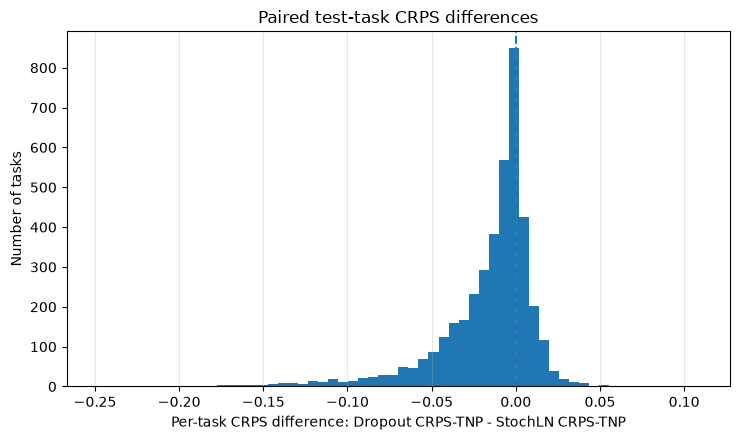

Wrote: /scratch2/ij292/tnp-crps/results/tabular/tabicl_nc128_500_test_v1/notebook_outputs/dropout_minus_stochln_crps.png


In [9]:
pivot_crps = per_task.pivot(
    index="task_index",
    columns="model_name",
    values="crps",
).sort_index()

difference_specs = [
    (
        "dropout",
        "gaussian",
        "dropout_minus_gaussian_crps.png",
    ),
    (
        "stochln",
        "gaussian",
        "stochln_minus_gaussian_crps.png",
    ),
    (
        "dropout",
        "stochln",
        "dropout_minus_stochln_crps.png",
    ),
]

for first, second, filename in difference_specs:
    differences = (
        pivot_crps[first]
        - pivot_crps[second]
    )

    fig, ax = plt.subplots(
        figsize=(7.5, 4.5)
    )

    ax.hist(
        differences,
        bins=60,
    )
    ax.axvline(
        0.0,
        linestyle="--",
    )

    ax.set_xlabel(
        f"Per-task CRPS difference: "
        f"{MODEL_LABELS[first]} - "
        f"{MODEL_LABELS[second]}"
    )
    ax.set_ylabel("Number of tasks")
    ax.set_title(
        "Paired test-task CRPS differences"
    )
    ax.grid(
        axis="x",
        alpha=0.3,
    )

    fig.tight_layout()

    figure_path = (
        OUTPUT_DIR / filename
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Wrote:", figure_path)

In [12]:
best_model = aggregate.iloc[0]

print(
    "Best aggregate CRPS:",
    best_model["model"],
    f"{best_model['crps']:.6f}",
)
print()

for _, row in bootstrap_crps.iterrows():
    print(
        f"{row['comparison']}: "
        f"difference={row['mean_paired_difference']:.6f}, "
        f"95% CI=[{row['ci95_lower']:.6f}, "
        f"{row['ci95_upper']:.6f}], "
        f"{row['conclusion']}."
    )

print()
print(
    "Interpretation guard: describe a pairwise advantage as "
    "bootstrap-supported only when its 95% paired interval "
    "excludes zero."
)

Best aggregate CRPS: Dropout CRPS-TNP 0.274667

Dropout CRPS-TNP - Gaussian TNP: difference=-0.046228, 95% CI=[-0.048007, -0.044490], Dropout CRPS-TNP lower.
StochLN CRPS-TNP - Gaussian TNP: difference=-0.029406, 95% CI=[-0.031148, -0.027725], StochLN CRPS-TNP lower.
Dropout CRPS-TNP - StochLN CRPS-TNP: difference=-0.016822, 95% CI=[-0.017779, -0.015884], Dropout CRPS-TNP lower.
Dropout CRPS-TNP - Context resample: difference=-0.202230, 95% CI=[-0.208338, -0.195933], Dropout CRPS-TNP lower.
StochLN CRPS-TNP - Context resample: difference=-0.185408, 95% CI=[-0.191370, -0.179355], StochLN CRPS-TNP lower.
Gaussian TNP - Context resample: difference=-0.156002, 95% CI=[-0.162737, -0.149082], Gaussian TNP lower.

Interpretation guard: describe a pairwise advantage as bootstrap-supported only when its 95% paired interval excludes zero.


The primary comparison is marginal CRPS, because all models were scored with
the same fair-CRPS convention on the same held-out tasks.

The energy score is a function-level diagnostic over the complete target
vector. It should be reported separately from marginal CRPS: a model may rank
differently on the two metrics.

Coverage should be interpreted together with interval width and spread–skill
ratio. Higher coverage alone is not necessarily better when it is achieved by
substantially wider intervals.

This notebook is the permanent analysis artifact for the locked fixed-\(N_c=128\)
test result. It does not perform checkpoint selection or model tuning.